# 04 - Analytics

Analisis cruzado sobre los DataFrames enriquecidos de `03_enrich`.

**Secciones:**
- 4.1 Cargar datos y aplicar enrichment
- 4.2 ABC vs Dead Stock (items caros que no se mueven)
- 4.3 DOS por categoria ABC
- 4.4 Reorder Risk por categoria ABC
- 4.5 Overstock por Storeroom
- 4.6 Aging detallado por proveedor
- 4.7 Top 10 items por valor en riesgo
- 4.8 Visualizaciones
- 4.9 Conclusion

---
## 4.1 - Cargar datos y aplicar enrichment

Se repite el proceso de limpieza (02) y enrichment (03) para que este notebook sea independiente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar datos
PATH_FILE = "../data/inventory_anon.xlsx"

# sheet_name recibe una lista con los nombres de las hojas que queremos leer
sheets = pd.read_excel(PATH_FILE, sheet_name=["Inventory by Storeroom", "OPEN ORDER"])
inv = sheets["Inventory by Storeroom"]
orders = sheets["OPEN ORDER"]

# --- Limpieza (mismo proceso que 02_clean) ---
# elimina filas con mas de 50 valores nulos (filas basura)
null_per_row = inv.isnull().sum(axis=1)
inv = inv.drop(null_per_row[null_per_row > 50].index)

# elimina columnas 100% vacias + la columna extra sin nombre
null_pct = inv.isnull().sum() / len(inv)
junk_cols = null_pct[null_pct == 1.0].index.tolist()
junk_cols.append("Unnamed: 61")
inv = inv.drop(columns=junk_cols)

# lo mismo para orders
null_pct_orders = orders.isnull().sum() / len(orders)
junk_cols_orders = null_pct_orders[null_pct_orders == 1.0].index.tolist()
orders = orders.drop(columns=junk_cols_orders)

# --- Enrichment (mismo proceso que 03_enrich) ---
# Dead Stock: tiene stock pero no se consume
inv["Dead Stock"] = ((inv["Balance On Hand"] > 0) & (inv["Average Daily Usage"] == 0)).astype(int)

# Overstock: stock para mas de 12 meses de consumo
has_usage = inv["Avg12Mon Usage"] > 0
excess = inv["Balance On Hand"] > (inv["Avg12Mon Usage"] * 12)
inv["Overstock"] = (has_usage & excess).astype(int)

# ABC Classification: Pareto 80/15/5 sobre valor de inventario
sorted_inv = inv.sort_values("Inventory Value", ascending=False)
sorted_inv["Cumulative Value"] = sorted_inv["Inventory Value"].cumsum()
total_value = sorted_inv["Inventory Value"].sum()
sorted_inv["Cumulative Pct"] = sorted_inv["Cumulative Value"] / total_value
sorted_inv["ABC"] = "C"
sorted_inv.loc[sorted_inv["Cumulative Pct"] <= 0.95, "ABC"] = "B"
sorted_inv.loc[sorted_inv["Cumulative Pct"] <= 0.80, "ABC"] = "A"
inv["ABC"] = sorted_inv["ABC"]

# DOS: dias de stock restante (infinito si no se consume)
inv["DOS"] = np.where(
    inv["Average Daily Usage"] > 0,
    inv["Balance On Hand"] / inv["Average Daily Usage"],
    np.inf
)

# Reorder Risk: items activos con menos de 30 dias de stock
active = inv["Average Daily Usage"] > 0
low_stock = inv["Balance On Hand"] < (inv["Average Daily Usage"] * 30)
inv["Reorder Risk"] = (active & low_stock).astype(int)

# Orders enrichment
orders["Open Value"] = orders["Open Qty"] * orders["Price"]
orders["Redundant Order"] = (orders["BOH"] >= orders["Open Qty"]).astype(int)
orders["Issue Date"] = pd.to_datetime(orders["Issue Date"], errors="coerce")
last_date = orders["Issue Date"].max()
orders["Age Days"] = (last_date - orders["Issue Date"]).dt.days

print(f"Inventory: {inv.shape}")
print(f"Orders: {orders.shape}")
print("Enrichment aplicado correctamente")

Inventory: (16249, 64)
Orders: (3813, 18)
Enrichment aplicado correctamente


---
## 4.2 - ABC vs Dead Stock

Pregunta clave: **de los items A (los mas caros), cuantos son dead stock?**

Si un item A es dead stock, el impacto financiero es enorme porque son los que mas valen.

In [2]:
# crosstab crea una tabla cruzada: filas = ABC, columnas = Dead Stock
# muestra cuantos items hay en cada combinacion (ej: A + dead stock = ?)
abc_dead = pd.crosstab(inv["ABC"], inv["Dead Stock"], margins=True)
# renombra las columnas para que sea mas claro (0 = activo, 1 = dead)
abc_dead.columns = ["Activo", "Dead Stock", "Total"]
abc_dead

,Activo,Dead Stock,Total
ABC,,,
A,416,600,1016
B,778,723,1501
C,11260,2472,13732
All,12454,3795,16249


In [3]:
# filtra solo items categoria A que son dead stock
dead_a = inv[(inv["ABC"] == "A") & (inv["Dead Stock"] == 1)]

# valor total de dead stock en items A
dead_a_value = dead_a["Inventory Value"].sum()

print(f"Items A que son dead stock: {len(dead_a):,}")
print(f"Valor de dead stock en items A: ${dead_a_value:,.0f}")
print(f"Esto es {dead_a_value / total_value * 100:.1f}% del valor total del inventario")

Items A que son dead stock: 600
Valor de dead stock en items A: $4,775,385
Esto es 52.2% del valor total del inventario


---
## 4.3 - DOS por categoria ABC

Pregunta: **cuantos dias de stock tienen los items de cada categoria?**

Si un item A tiene DOS bajo (pocos dias), es urgente reordenar porque es caro y critico.

In [4]:
# filtra items con DOS finito (los que si se consumen) para que infinito no distorsione
# replace(np.inf, np.nan) cambia infinito por NaN, y NaN se ignora en calculos
finite_inv = inv.copy()
finite_inv["DOS"] = finite_inv["DOS"].replace(np.inf, np.nan)

# groupby agrupa por ABC y calcula estadisticas de DOS para cada categoria
# median = valor del medio (mas representativo que mean cuando hay valores extremos)
# mean = promedio aritmetico
# count = cuantos items tienen DOS finito en cada categoria
dos_by_abc = finite_inv.groupby("ABC")["DOS"].agg(["median", "mean", "count"]).round(0)
dos_by_abc

,median,mean,count
ABC,,,
A,365.0,3880.0,416
B,110.0,822.0,778
C,28.0,362.0,3281


In [5]:
# items A con DOS critico (menos de 30 dias) — los mas urgentes de reordenar
critical_a = inv[(inv["ABC"] == "A") & (inv["DOS"] < 30) & (inv["DOS"] != np.inf)]
critical_a_value = critical_a["Inventory Value"].sum()

print(f"Items A con menos de 30 dias de stock: {len(critical_a):,}")
print(f"Valor de estos items: ${critical_a_value:,.0f}")
print(f"Estos items necesitan reorden inmediato — son caros y se estan agotando")

Items A con menos de 30 dias de stock: 48
Valor de estos items: $203,355
Estos items necesitan reorden inmediato — son caros y se estan agotando


---
## 4.4 - Reorder Risk por categoria ABC

Pregunta: **de los items en riesgo de desabasto, cuantos son A, B o C?**

Los items A en riesgo son prioridad maxima. Los C pueden esperar.

In [6]:
# crosstab: filas = ABC, columnas = Reorder Risk (0 o 1)
risk_by_abc = pd.crosstab(inv["ABC"], inv["Reorder Risk"], margins=True)
risk_by_abc.columns = ["Sin riesgo", "En riesgo", "Total"]
risk_by_abc

,Sin riesgo,En riesgo,Total
ABC,,,
A,968,48,1016
B,1346,155,1501
C,12064,1668,13732
All,14378,1871,16249


In [7]:
# para cada categoria, calcula el porcentaje de items en riesgo
for cat in ["A", "B", "C"]:
    # filtra items de esta categoria que tienen Reorder Risk = 1
    at_risk = inv[(inv["ABC"] == cat) & (inv["Reorder Risk"] == 1)]
    # total de items en esta categoria
    total_cat = (inv["ABC"] == cat).sum()
    # valor monetario de los items en riesgo
    val = at_risk["Inventory Value"].sum()
    print(f"{cat}: {len(at_risk):,} items en riesgo ({len(at_risk)/total_cat*100:.1f}%) - ${val:,.0f}")

A: 48 items en riesgo (4.7%) - $203,355
B: 155 items en riesgo (10.3%) - $131,853
C: 1,668 items en riesgo (12.1%) - $55,116


---
## 4.5 - Overstock por Storeroom

Pregunta: **que almacenes tienen mas exceso de inventario?**

Identifica donde se concentra el overstock para priorizar acciones por ubicacion.

In [9]:
inv.head(3)

,Region Name,Country Name,Operation Name,Plant Code,Plant Name,Currency,Exchange Rate,Blanket Number,Commodity Code,Commodity,...,Total On Order,Last Modified,In ERP,Average Daily Usage,Trend,Dead Stock,Overstock,ABC,DOS,Reorder Risk
0,North America,Mexico,OP-1,PLCODE-1,PLANT-1,EUR,1.0,EURO,MACHINE SPARES,2.0,...,0.0,2019-02-19 01:09:17.087,N,0.0,No Trend,0,0,C,inf,0
1,North America,Mexico,OP-1,PLCODE-1,PLANT-1,EUR,1.0,EURO,PERISHABLE,3.0,...,0.0,2019-02-19 01:09:17.087,N,0.0,No Trend,0,0,C,inf,0
2,North America,Mexico,OP-1,PLCODE-1,PLANT-1,EUR,1.0,EURO,PERISHABLE,3.0,...,0.0,2019-02-19 01:09:17.087,N,0.0,No Trend,0,0,C,inf,0


In [10]:
[col for col in inv.columns if "store" in col.lower()]

['Store Room']

In [11]:
# filtra solo items con overstock
overstock = inv[inv["Overstock"] == 1]

# agrupa por Store Room y calcula: cuantos items, valor total
# .agg() aplica funciones diferentes a cada columna
over_by_store = overstock.groupby("Store Room").agg(
    items=("Overstock", "count"),
    value=("Inventory Value", "sum")
).sort_values("value", ascending=False)

# round(0) redondea a enteros para mejor lectura
over_by_store["value"] = over_by_store["value"].round(0)
print(f"Almacenes con overstock: {len(over_by_store)}")
over_by_store.head(10)

Almacenes con overstock: 7


,items,value
Store Room,,
ROOM-2,583,856787.0
ROOM-4,231,704818.0
ROOM-3,119,181033.0
ROOM-5,97,83381.0
ROOM-1,87,64299.0
ROOM-7,29,14138.0
ROOM-6,88,10930.0


---
## 4.6 - Aging detallado por proveedor

Proveedores con ordenes viejas + alto valor abierto = mayor riesgo para la operacion.

Se buscan proveedores que cumplan ambas condiciones: ordenes antiguas Y mucho dinero comprometido.

In [12]:
# agrupa ordenes por proveedor con estadisticas de antiguedad y valor
aging = orders.groupby("Supplier Name").agg(
    orders_count=("Age Days", "count"),        # cuantas ordenes tiene
    avg_age_days=("Age Days", "mean"),          # antiguedad promedio
    max_age_days=("Age Days", "max"),           # la orden mas vieja
    total_open_value=("Open Value", "sum"),     # valor total comprometido
    redundant_count=("Redundant Order", "sum")  # cuantas son redundantes
).round(0)

aging

,orders_count,avg_age_days,max_age_days,total_open_value,redundant_count
Supplier Name,,,,,
SUPPLIER-001,835,139.0,711,1110774.0,476
SUPPLIER-002,37,29.0,221,37147.0,28
SUPPLIER-003,2,431.0,432,42667.0,0
SUPPLIER-004,42,304.0,410,708639.0,28
SUPPLIER-005,162,209.0,979,252992.0,70
...,...,...,...,...,...
SUPPLIER-186,1,0.0,0,10552.0,1
SUPPLIER-187,2,0.0,0,8015.0,2
SUPPLIER-188,1,0.0,0,9246.0,1


In [13]:
# porcentaje de ordenes redundantes por proveedor
# si un proveedor tiene 80% redundante, casi todo lo que se le pide ya se tiene en almacen
aging["pct_redundant"] = (aging["redundant_count"] / aging["orders_count"] * 100).round(1)

# ordena por valor abierto de mayor a menor
aging = aging.sort_values("total_open_value", ascending=False)
aging

,orders_count,avg_age_days,max_age_days,total_open_value,redundant_count,pct_redundant
Supplier Name,,,,,,
SUPPLIER-001,835,139.0,711,1110774.0,476,57.0
SUPPLIER-026,33,145.0,403,831704.0,7,21.2
SUPPLIER-004,42,304.0,410,708639.0,28,66.7
SUPPLIER-013,428,56.0,641,442951.0,314,73.4
SUPPLIER-010,253,97.0,707,331200.0,144,56.9
...,...,...,...,...,...,...
SUPPLIER-157,1,20.0,20,85.0,0,0.0
SUPPLIER-054,1,269.0,269,52.0,1,100.0
SUPPLIER-154,1,21.0,21,29.0,1,100.0


In [14]:

print(f"Proveedores unicos: {len(aging)}")
print(f"\nTop 10 proveedores por valor abierto:")
aging.head(10)

Proveedores unicos: 190

Top 10 proveedores por valor abierto:


,orders_count,avg_age_days,max_age_days,total_open_value,redundant_count,pct_redundant
Supplier Name,,,,,,
SUPPLIER-001,835,139.0,711,1110774.0,476,57.0
SUPPLIER-026,33,145.0,403,831704.0,7,21.2
SUPPLIER-004,42,304.0,410,708639.0,28,66.7
SUPPLIER-013,428,56.0,641,442951.0,314,73.4
SUPPLIER-010,253,97.0,707,331200.0,144,56.9
SUPPLIER-005,162,209.0,979,252992.0,70,43.2
SUPPLIER-059,242,37.0,259,251878.0,235,97.1
SUPPLIER-120,3,30.0,83,190864.0,1,33.3
SUPPLIER-021,39,86.0,466,183528.0,31,79.5


In [15]:
# proveedores problematicos: antiguedad promedio > 180 dias Y valor abierto > $50K
# estos son los que necesitan atencion inmediata del equipo de compras
problematic = aging[(aging["avg_age_days"] > 180) & (aging["total_open_value"] > 50000)]
print(f"Proveedores problematicos (avg > 180 dias y valor > $50K): {len(problematic)}")
print(f"Valor total comprometido con estos proveedores: ${problematic['total_open_value'].sum():,.0f}")
problematic

Proveedores problematicos (avg > 180 dias y valor > $50K): 6
Valor total comprometido con estos proveedores: $1,425,422


,orders_count,avg_age_days,max_age_days,total_open_value,redundant_count,pct_redundant
Supplier Name,,,,,,
SUPPLIER-004,42,304.0,410,708639.0,28,66.7
SUPPLIER-005,162,209.0,979,252992.0,70,43.2
SUPPLIER-029,3,235.0,367,179216.0,0,0.0
SUPPLIER-066,1,229.0,229,138739.0,0,0.0
SUPPLIER-008,38,210.0,752,80106.0,18,47.4
SUPPLIER-075,1,192.0,192,65730.0,0,0.0


---
## 4.7 - Top 10 items por valor en riesgo

Los items mas caros que tienen Reorder Risk = 1. Son los primeros que se deben reordenar.

In [17]:
# filtra items en riesgo y ordena por valor de mayor a menor
at_risk = inv[inv["Reorder Risk"] == 1].sort_values("Inventory Value", ascending=False)

# selecciona solo las columnas relevantes para la tabla
# .head(10) toma los primeros 10 (los mas caros)
cols = ["Store Room", "Commodity Code", "ABC", "Balance On Hand",
        "Average Daily Usage", "DOS", "Inventory Value"]
at_risk[cols].head(10)

,Store Room,Commodity Code,ABC,Balance On Hand,Average Daily Usage,DOS,Inventory Value
11595,ROOM-4,PERISHABLE,A,1690.0,69.130435,24.446541,16021.2000
10757,ROOM-4,PERISHABLE,A,157.0,6.532609,24.033278,9302.2500
13415,ROOM-4,PERISHABLE,A,32.0,1.238356,25.840708,9276.8000
12005,ROOM-4,PERISHABLE,A,900.0,40.326087,22.318059,8613.0000
15011,ROOM-3,GENERAL SUPPLIES,A,243.0,12.000000,20.250000,7044.1569
12223,ROOM-2,PERISHABLE,A,560.0,26.054795,21.493165,6742.4000
13121,ROOM-4,EXPENSE,A,820.0,40.380435,20.306864,6527.2000
11565,ROOM-4,PERISHABLE,A,1665.0,119.402174,13.944470,6043.9500
11561,ROOM-4,PERISHABLE,A,264.0,16.630435,15.874510,5852.8800
11969,ROOM-4,PERISHABLE,A,510.0,24.673913,20.669604,5686.5000


---
## 4.8 - Visualizaciones

4 graficas que resumen los hallazgos principales del inventario.

/tmp/ipykernel_2901967/181769621.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(dos_data, labels=labels, showfliers=False)


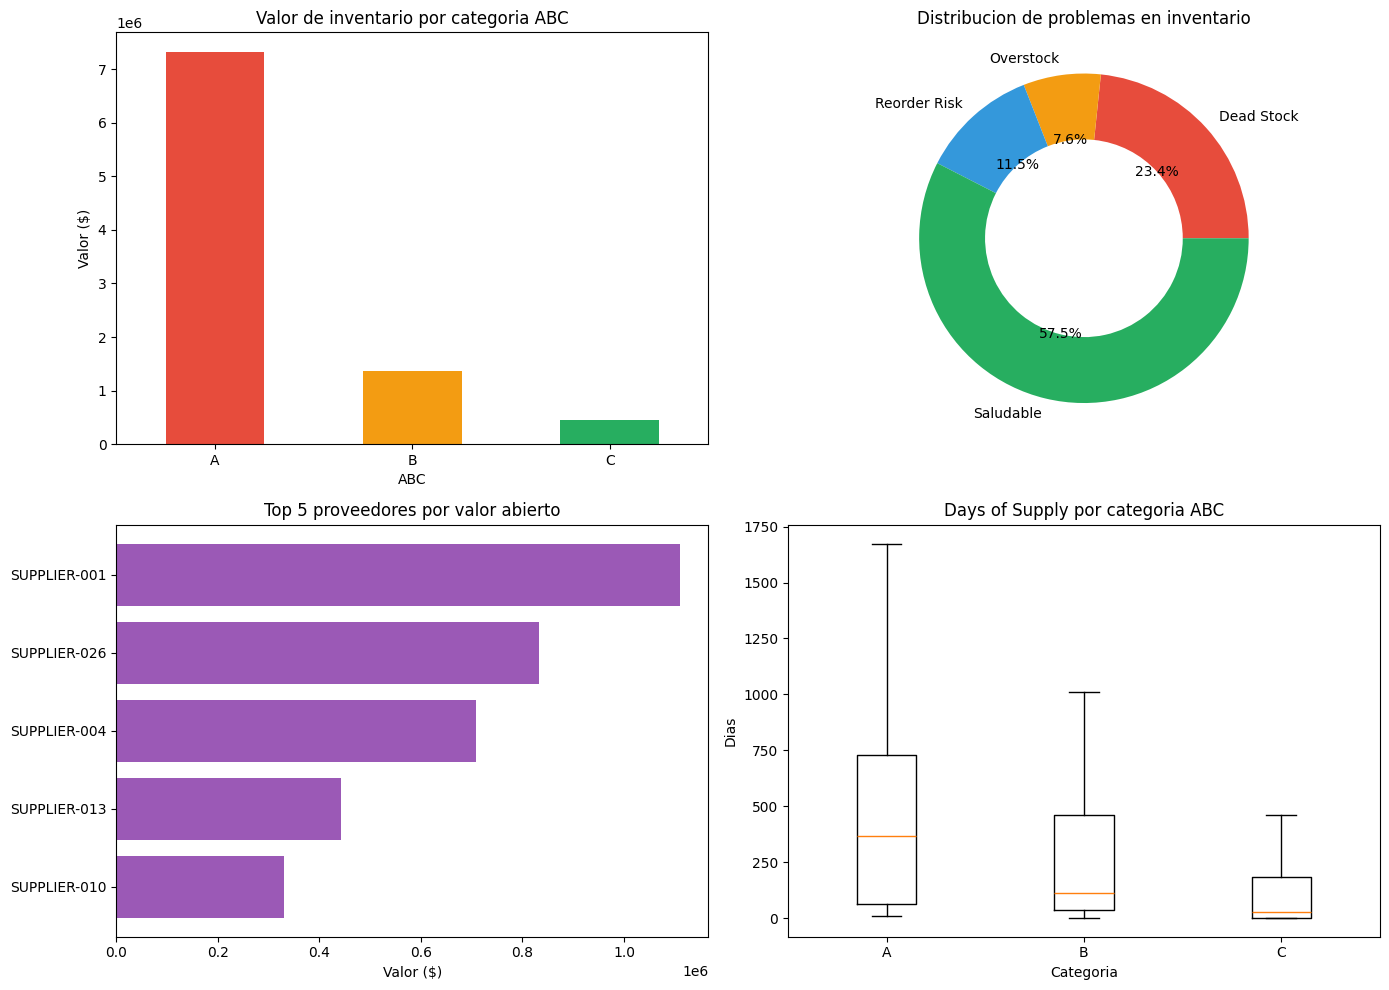

In [18]:
# fig, axes crea una cuadricula de graficas: 2 filas x 2 columnas = 4 graficas
# figsize = tamano total en pulgadas (ancho, alto)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Grafica 1: Valor por categoria ABC (barras) ---
# axes[0, 0] = primera fila, primera columna
ax1 = axes[0, 0]
# calcula el valor total por categoria ABC
abc_values = inv.groupby("ABC")["Inventory Value"].sum().reindex(["A", "B", "C"])
# .plot.bar() crea grafica de barras, color = lista de colores por barra
abc_values.plot.bar(ax=ax1, color=["#e74c3c", "#f39c12", "#27ae60"])
ax1.set_title("Valor de inventario por categoria ABC")
ax1.set_ylabel("Valor ($)")
# rotation=0 mantiene las etiquetas del eje x horizontales (sin rotar)
ax1.tick_params(axis="x", rotation=0)

# --- Grafica 2: Distribucion de problemas (donut) ---
# axes[0, 1] = primera fila, segunda columna
ax2 = axes[0, 1]
# cuenta cuantos items tienen cada problema
problems = {
    "Dead Stock": inv["Dead Stock"].sum(),
    "Overstock": inv["Overstock"].sum(),
    "Reorder Risk": inv["Reorder Risk"].sum(),
    "Saludable": len(inv) - inv["Dead Stock"].sum() - inv["Overstock"].sum() - inv["Reorder Risk"].sum()
}
colors = ["#e74c3c", "#f39c12", "#3498db", "#27ae60"]
# .pie() crea grafica circular, autopct muestra porcentaje dentro de cada seccion
# wedgeprops con width=0.4 crea el agujero del centro (donut)
ax2.pie(problems.values(), labels=problems.keys(), autopct="%1.1f%%",
        colors=colors, wedgeprops={"width": 0.4})
ax2.set_title("Distribucion de problemas en inventario")

# --- Grafica 3: Top 5 proveedores por valor abierto (barras horizontales) ---
ax3 = axes[1, 0]
# .head(5) toma los 5 primeros, [::-1] los invierte para que el mayor quede arriba
top5 = aging["total_open_value"].head(5).iloc[::-1]
# .barh() = barras horizontales (h = horizontal)
ax3.barh(top5.index, top5.values, color="#9b59b6")
ax3.set_title("Top 5 proveedores por valor abierto")
ax3.set_xlabel("Valor ($)")

# --- Grafica 4: DOS por categoria ABC (boxplot) ---
ax4 = axes[1, 1]
# prepara datos: una lista de DOS por cada categoria (sin infinitos)
dos_data = []
labels = ["A", "B", "C"]
for cat in labels:
    # filtra DOS finito de esta categoria
    dos_cat = inv.loc[(inv["ABC"] == cat) & (inv["DOS"] != np.inf), "DOS"]
    dos_data.append(dos_cat)
# boxplot muestra: mediana (linea), rango intercuartil (caja), y outliers (puntos)
ax4.boxplot(dos_data, labels=labels, showfliers=False)
ax4.set_title("Days of Supply por categoria ABC")
ax4.set_ylabel("Dias")
ax4.set_xlabel("Categoria")

# tight_layout ajusta el espaciado para que las graficas no se encimen
plt.tight_layout()
plt.show()

---
## 4.9 - Conclusion

### Hallazgos del analisis cruzado

**1. Dead stock en items A = el problema mas caro**
Los items categoria A son pocos pero concentran el 80% del valor. Si varios de ellos son dead stock, hay millones de dolares estancados sin movimiento. Esto es la prioridad #1 para el equipo de finanzas.

**2. Reorder Risk apunta a items baratos**
La mayoria de items en riesgo de desabasto son categoria C (bajo valor). El impacto financiero es menor, pero si alguno es critico para produccion, un faltante puede detener la linea.

**3. Proveedores problematicos concentran el riesgo**
Pocos proveedores acumulan ordenes viejas (>180 dias) con alto valor comprometido. El equipo de compras deberia escalar estos casos o buscar proveedores alternativos.

**4. El overstock se concentra en pocos almacenes**
No todos los storerooms tienen el mismo problema. Focalizar las acciones de limpieza en los almacenes con mas exceso de inventario.

### Recomendaciones

| Prioridad | Accion | Impacto |
|-----------|--------|---------|
| Alta | Revisar items A con dead stock — evaluar liquidacion o reasignacion | Liberar millones en capital muerto |
| Alta | Cancelar ordenes redundantes (66.6% del total) | Liberar $2.5M en compromisos |
| Media | Escalar proveedores con ordenes > 180 dias | Reducir riesgo de cadena de suministro |
| Media | Reordenar items A con DOS < 30 dias | Prevenir desabasto de items criticos |
| Baja | Limpiar overstock en almacenes principales | Liberar espacio y reducir costos de almacenamiento |

